In [1]:
specfn = '/orange/adamginsburg/jwst/cloudc/spectra/J110621_JWST_NIRSpec_FS_spectrum_McClure23.txt'

In [2]:
!head -n 13 $specfn

;;; JWST NIRSpec FS spectrum of J110621.
;;;
;;; Reduced by Klaus Pontoppidan using the STScI JWST
;;; pipeline detector level 1 processing using version 1.7.1, 
;;; Calibration Reference Data System (CRDS) context
;;; jwst_0948.pmap, and the PUB CRDS server. 
;;;
;;; Published in McClure et al. (2023), Nature Astronomy.
;;; Full observational and data reduction details given 
;;; in the Methods section of that publication.
;;;
;;; Wavelength (micron), Flux (mJy), u_Flux (mJy)
       2.7388065     0.017442079    0.0029359214


In [3]:
from astropy.table import Table
from astropy import units as u
spectable = Table.read(specfn, format='ascii', comment=';',)
spectable.rename_column('col1', 'wavelength')
spectable['wavelength'].unit = u.um
spectable.rename_column('col2', 'flux')
spectable['flux'].unit = u.mJy

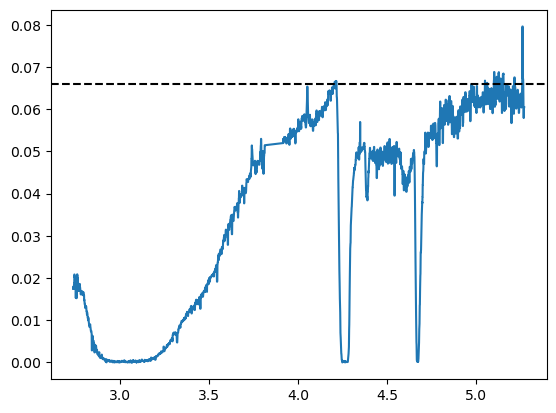

In [4]:
import pylab as pl
pl.plot(spectable['wavelength'], spectable['flux']);
pl.axhline(0.066, color='k', linestyle='--');

-1.2579315647067322e+19 1 / cm2 -138.37247211774056 1 / cm


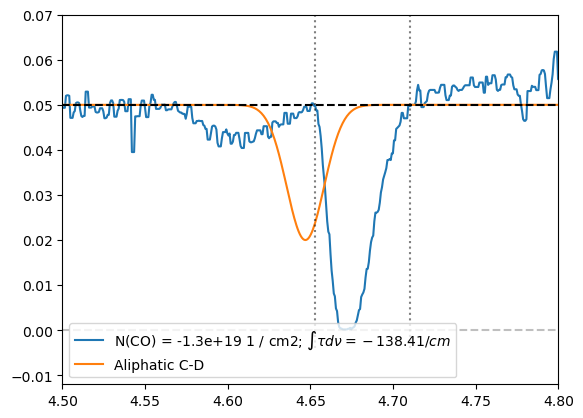

In [18]:
import numpy as np
import pylab as pl
cont = 0.050
lam_min, lam_max = 4.653, 4.71
freq = spectable['wavelength'].to(u.cm**-1, u.spectral())
dnu = np.abs(np.diff(freq))

A = 1.1e-17*u.cm

sel = (spectable['wavelength'] > lam_min*u.um) & (spectable['wavelength'] < lam_max*u.um)
tau = np.log((cont*u.mJy / spectable['flux'])) 
inttaudnu = (dnu[sel[:-1]] * tau[sel]).sum().to(u.cm**-1)
N = (inttaudnu / A).to(u.cm**-2)
print(N, inttaudnu)


pl.plot(spectable['wavelength'], spectable['flux'], label=f'N(CO) = {N:0.1e}; $\\int \\tau d\\nu = {inttaudnu:0.1f}$');
pl.plot(spectable['wavelength'], 0.05 - 0.03 * np.exp(-(spectable['wavelength'] - 4.647*u.um)**2 / (2*(0.0265/2.35*u.um)**2)), label='Aliphatic C-D')
pl.axhline(cont, color='k', linestyle='--');
pl.axhline(0, color='k', linestyle='--', alpha=0.25);
pl.vlines([lam_min, lam_max], *pl.ylim(), color='k', linestyle=':', alpha=0.5)
pl.legend(loc='lower left')
pl.xlim(4.5, 4.80);
pl.ylim(-0.012, 0.07);

-1.2579315647067322e+19 1 / cm2 -138.37247211774056 1 / cm


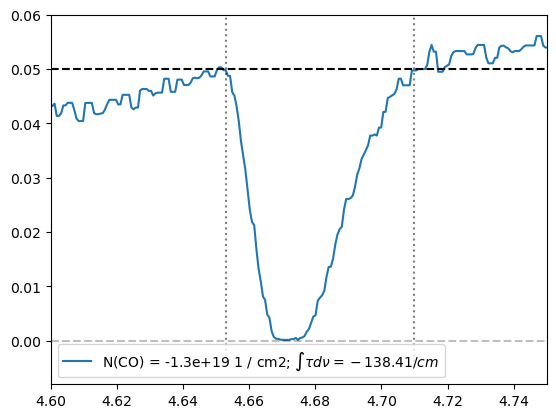

In [17]:
import numpy as np
import pylab as pl
cont = 0.050
lam_min, lam_max = 4.653, 4.71
freq = spectable['wavelength'].to(u.cm**-1, u.spectral())
dnu = np.abs(np.diff(freq))

A = 1.1e-17*u.cm

sel = (spectable['wavelength'] > lam_min*u.um) & (spectable['wavelength'] < lam_max*u.um)
tau = np.log((cont*u.mJy / spectable['flux'])) 
inttaudnu = (dnu[sel[:-1]] * tau[sel]).sum().to(u.cm**-1)
N = (inttaudnu / A).to(u.cm**-2)
print(N, inttaudnu)


pl.plot(spectable['wavelength'], spectable['flux'], label=f'N(CO) = {N:0.1e}; $\\int \\tau d\\nu = {inttaudnu:0.1f}$');
pl.axhline(cont, color='k', linestyle='--');
pl.axhline(0, color='k', linestyle='--', alpha=0.25);
pl.vlines([lam_min, lam_max], *pl.ylim(), color='k', linestyle=':', alpha=0.5)
pl.legend(loc='lower left')
pl.xlim(4.6, 4.75);
pl.ylim(-0.008, 0.06);

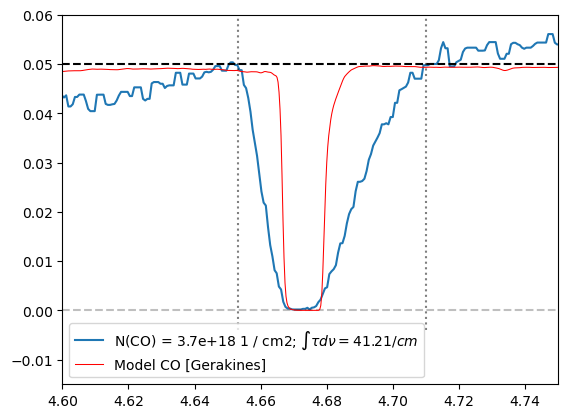

In [6]:
from icemodels.core import absorbed_spectrum, retrieve_gerakines_co, read_lida_file, read_ocdb_file, optical_constants_cache_dir
co_gera = retrieve_gerakines_co()
xarr = np.linspace(4.6, 4.75, 500)*u.um
yarr = np.ones(xarr.size) * cont
absspec = absorbed_spectrum(xarr=xarr, spectrum=yarr, ice_column=N, ice_model_table=co_gera)

pl.plot(spectable['wavelength'], spectable['flux'], label=f'N(CO) = {N:0.1e}; $\\int \\tau d\\nu = {inttaudnu:0.1f}$');
pl.axhline(cont, color='k', linestyle='--');
pl.axhline(0, color='k', linestyle='--', alpha=0.25);
pl.vlines([lam_min, lam_max], *pl.ylim(), color='k', linestyle=':', alpha=0.5)
pl.plot(xarr, absspec, color='r', linewidth=0.75, label='Model CO [Gerakines]');
pl.legend(loc='lower left')
pl.xlim(4.6, 4.75);
pl.ylim(-0.015, 0.06);

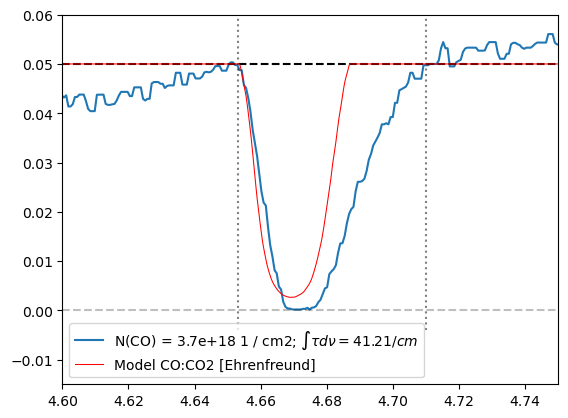

In [7]:
coco2 = read_lida_file(f'{optical_constants_cache_dir}/60_CO:CO2_1:1_25.0K.txt')

xarr = np.linspace(4.6, 4.75, 500)*u.um
yarr = np.ones(xarr.size) * cont
absspec = absorbed_spectrum(xarr=xarr, spectrum=yarr, ice_column=N, ice_model_table=coco2)

pl.plot(spectable['wavelength'], spectable['flux'], label=f'N(CO) = {N:0.1e}; $\\int \\tau d\\nu = {inttaudnu:0.1f}$');
pl.axhline(cont, color='k', linestyle='--');
pl.axhline(0, color='k', linestyle='--', alpha=0.25);
pl.vlines([lam_min, lam_max], *pl.ylim(), color='k', linestyle=':', alpha=0.5)
pl.plot(xarr, absspec, color='r', linewidth=0.75, label='Model CO:CO2 [Ehrenfreund]');
pl.legend(loc='lower left')
pl.xlim(4.6, 4.75);
pl.ylim(-0.015, 0.06);

In [8]:
coco2[(coco2['Wavelength'] > 4.6*u.um) & (coco2['Wavelength'] < 4.75*u.um)][::100]

Wavenumber,k,Wavelength
1 / cm,,um
float64,float64,float64
2105.3,-0.02436,4.7499168764546615
2117.35,-0.0234,4.722884737997969
2129.41,-0.01997,4.696136488510902
2141.46,0.3982,4.669711318446294
2153.52,-0.02171,4.6435603105613135
2165.57,-0.02392,4.617721893081267


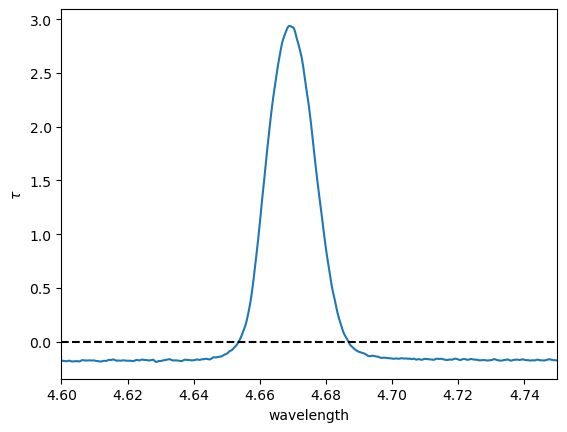

In [9]:
#pl.plot(coco2['Wavelength'], coco2['k'])
pl.plot(xarr, absorbed_spectrum(xarr=xarr, spectrum=yarr, ice_column=N, ice_model_table=coco2, return_tau=True))
pl.xlim(4.6, 4.75);
pl.ylabel('$\\tau$')
pl.xlabel("wavelength");
pl.axhline(0, linestyle='--', color='k');

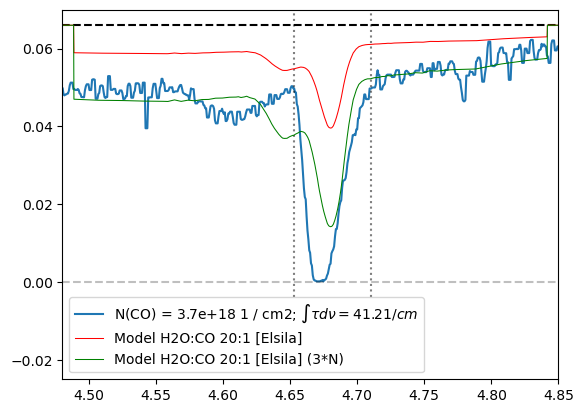

In [10]:
h2oco = read_ocdb_file(f'{optical_constants_cache_dir}/39_H2O:CO_(20:1)_12K_Elsila.txt')

cont = 0.066
xarr = np.linspace(4.48, 4.85, 1500)*u.um
yarr = np.ones(xarr.size) * cont
absspec = absorbed_spectrum(xarr=xarr, spectrum=yarr, ice_column=N, ice_model_table=h2oco)
absspec2 = absorbed_spectrum(xarr=xarr, spectrum=yarr, ice_column=N*3, ice_model_table=h2oco)

pl.plot(spectable['wavelength'], spectable['flux'], label=f'N(CO) = {N:0.1e}; $\\int \\tau d\\nu = {inttaudnu:0.1f}$');
pl.axhline(cont, color='k', linestyle='--');
pl.axhline(0, color='k', linestyle='--', alpha=0.25);
pl.vlines([lam_min, lam_max], *pl.ylim(), color='k', linestyle=':', alpha=0.5)
pl.plot(xarr, absspec, color='r', linewidth=0.75, label='Model H2O:CO 20:1 [Elsila]');
pl.plot(xarr, absspec2, color='g', linewidth=0.75, label='Model H2O:CO 20:1 [Elsila] (3*N)');
pl.legend(loc='lower left')
pl.xlim(4.48, 4.85);
pl.ylim(-0.025, 0.07);

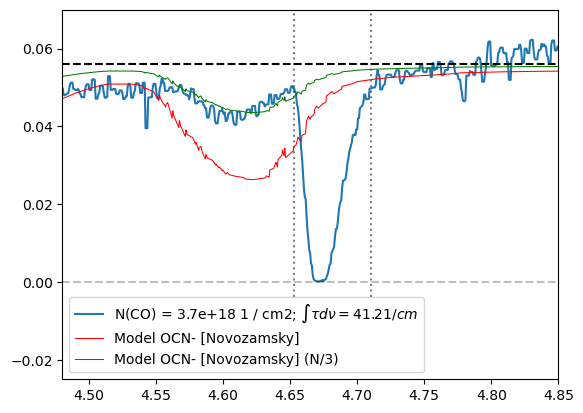

In [11]:
ocn = read_lida_file(f'{optical_constants_cache_dir}/158_OCN-_1_12.0K.txt')

cont = 0.056
xarr = np.linspace(4.48, 4.85, 1500)*u.um
yarr = np.ones(xarr.size) * cont
absspec = absorbed_spectrum(xarr=xarr, spectrum=yarr, ice_column=N, ice_model_table=ocn)
absspec2 = absorbed_spectrum(xarr=xarr, spectrum=yarr, ice_column=N/3, ice_model_table=ocn)

pl.plot(spectable['wavelength'], spectable['flux'], label=f'N(CO) = {N:0.1e}; $\\int \\tau d\\nu = {inttaudnu:0.1f}$');
pl.axhline(cont, color='k', linestyle='--');
pl.axhline(0, color='k', linestyle='--', alpha=0.25);
pl.vlines([lam_min, lam_max], *pl.ylim(), color='k', linestyle=':', alpha=0.5)
pl.plot(xarr, absspec, color='r', linewidth=0.75, label='Model OCN- [Novozamsky]');
pl.plot(xarr, absspec2, color='g', linewidth=0.75, label='Model OCN- [Novozamsky] (N/3)');
pl.legend(loc='lower left')
pl.xlim(4.48, 4.85);
pl.ylim(-0.025, 0.07);

In [12]:
from icemodels import fluxes_in_filters

from astroquery.svo_fps import SvoFps
jfilts = SvoFps.get_filter_list('JWST')
jfilts.add_index('filterID')

filter_ids = ['JWST/NIRCam.F410M', 'JWST/NIRCam.F466N', 'JWST/NIRCam.F356W', 
             'JWST/NIRCam.F444W', 'JWST/NIRCam.F405N']
filter_data = {fid: float(jfilts.loc[fid]['ZeroPoint']) for fid in filter_ids}
transdata = {fid: SvoFps.get_transmission_data(fid) for fid in filter_ids}

cmd_x = ('JWST/NIRCam.F410M',
         'JWST/NIRCam.F466N',
         'JWST/NIRCam.F356W',
         'JWST/NIRCam.F444W',
         'JWST/NIRCam.F405N',
         )
flxd = fluxes_in_filters(spectable['wavelength'], spectable['flux'], filterids=cmd_x, transdata=transdata)

In [13]:
flxd

{'JWST/NIRCam.F410M': 0.04966345915528905,
 'JWST/NIRCam.F466N': 0.030359839525139293,
 'JWST/NIRCam.F356W': 0.028501456808703085,
 'JWST/NIRCam.F444W': 0.049197403824856815,
 'JWST/NIRCam.F405N': 0.05821839618921336}

In [14]:
%run /orange/adamginsburg/jwst/brick/analysis/iceage_fluxes.py
iceage_mags

{'JWST/NIRCam.F070W': 13.001578270610093,
 'JWST/NIRCam.F090W': 12.774021419539139,
 'JWST/NIRCam.F115W': 12.501188273055373,
 'JWST/NIRCam.F140M': 12.171340929068165,
 'JWST/NIRCam.F150W': 12.068376730746406,
 'JWST/NIRCam.F162M': 11.920734365248531,
 'JWST/NIRCam.F164N': 11.880231519132604,
 'JWST/NIRCam.F150W2': 12.047695335423771,
 'JWST/NIRCam.F182M': 11.7130732841893,
 'JWST/NIRCam.F187N': 11.646714809149234,
 'JWST/NIRCam.F200W': 11.594681398049476,
 'JWST/NIRCam.F210M': 11.490026781802683,
 'JWST/NIRCam.F212N': 11.468993022851341,
 'JWST/NIRCam.F250M': 11.15348251341732,
 'JWST/NIRCam.F277W': 11.522941942343834,
 'JWST/NIRCam.F300M': 13.660242960210313,
 'JWST/NIRCam.F323N': 12.731671674071736,
 'JWST/NIRCam.F322W2': 10.479149503239508,
 'JWST/NIRCam.F335M': 11.131861845612194,
 'JWST/NIRCam.F356W': 9.946827471681738,
 'JWST/NIRCam.F360M': 9.749065486460879,
 'JWST/NIRCam.F405N': 8.877114753735423,
 'JWST/NIRCam.F410M': 9.058976139719487,
 'JWST/NIRCam.F430M': 9.21406692839282,

# NIRSPEC archive

In [71]:
from astropy.table import Table
nirspec_dir = '/orange/adamginsburg/jwst/spectra/mastDownload/JWST/'
nirspecarchive_mags = Table.read(f'{nirspec_dir}/jwst_archive_spectra_as_fluxes.fits')
nirspecarchive_mags.add_index('Object')
nirspecarchive_mags.add_index('grating')
nirspecarchive_mags.loc[('Object', 'HOPS-383')].loc[('grating', 'PRISM')]

JWST/NIRCam.F070W,JWST/NIRCam.F090W,JWST/NIRCam.F115W,JWST/NIRCam.F140M,JWST/NIRCam.F150W,JWST/NIRCam.F162M,JWST/NIRCam.F164N,JWST/NIRCam.F150W2,JWST/NIRCam.F182M,JWST/NIRCam.F187N,JWST/NIRCam.F200W,JWST/NIRCam.F210M,JWST/NIRCam.F212N,JWST/NIRCam.F250M,JWST/NIRCam.F277W,JWST/NIRCam.F300M,JWST/NIRCam.F323N,JWST/NIRCam.F322W2,JWST/NIRCam.F335M,JWST/NIRCam.F356W,JWST/NIRCam.F360M,JWST/NIRCam.F405N,JWST/NIRCam.F410M,JWST/NIRCam.F430M,JWST/NIRCam.F444W,JWST/NIRCam.F460M,JWST/NIRCam.F466N,JWST/NIRCam.F470N,JWST/NIRCam.F480M,Target,Program,Object,grating
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bytes27,bytes5,bytes27,bytes5
17.21463657163536,16.781562359200354,16.216431648865274,15.669839261303522,15.471698161762927,15.217281362809974,15.151808365458974,15.348014819644526,14.874084408661245,14.554737330977126,14.734261203561484,14.622315203335358,14.5386553577294,14.08522133425336,14.33341416110112,15.070460367295821,13.91890856402643,13.70436687057073,13.364654868235046,13.263844628509215,13.234657872479232,12.530260666964319,12.805713803768558,12.669203368714587,12.332679075094932,12.147700750921365,12.383581888507447,11.991055944150444,11.8251495745636,HOPS-383,05804,HOPS-383,PRISM


In [73]:
nirspecarchive_mags.loc[('Object', 'PER-EMB-22')].loc[('grating', 'PRISM')]

JWST/NIRCam.F070W,JWST/NIRCam.F090W,JWST/NIRCam.F115W,JWST/NIRCam.F140M,JWST/NIRCam.F150W,JWST/NIRCam.F162M,JWST/NIRCam.F164N,JWST/NIRCam.F150W2,JWST/NIRCam.F182M,JWST/NIRCam.F187N,JWST/NIRCam.F200W,JWST/NIRCam.F210M,JWST/NIRCam.F212N,JWST/NIRCam.F250M,JWST/NIRCam.F277W,JWST/NIRCam.F300M,JWST/NIRCam.F323N,JWST/NIRCam.F322W2,JWST/NIRCam.F335M,JWST/NIRCam.F356W,JWST/NIRCam.F360M,JWST/NIRCam.F405N,JWST/NIRCam.F410M,JWST/NIRCam.F430M,JWST/NIRCam.F444W,JWST/NIRCam.F460M,JWST/NIRCam.F466N,JWST/NIRCam.F470N,JWST/NIRCam.F480M,Target,Program,Object,grating
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bytes27,bytes5,bytes27,bytes5
18.424982630633885,17.896090552106784,17.4304162850267,17.081092275463483,16.890496948708094,16.65172892929481,16.559707539523334,16.826733975166263,16.512258798521366,16.507074272842285,16.3294293375214,16.174279605026772,15.93478196982819,15.242091780320653,15.522402445385051,16.538345019809945,15.700755938618801,14.471259300816994,15.187533194984278,13.952671725900563,13.871447573022948,12.664253090623113,12.76751456508723,12.523685492473323,11.694535784098754,11.390088033017037,11.822831871318357,11.240503291167805,10.840835415509503,PER-EMB-22,01960,PER-EMB-22,PRISM


0.790360007839265
2.1082548618548316
1.0261538896348412
1.5364013273354864
-6.913635302853518
0.7145744606490751
2.0924349014439017
0.3187350973401166
1.145919589700636
-14.75615116505752
0.745214977357346


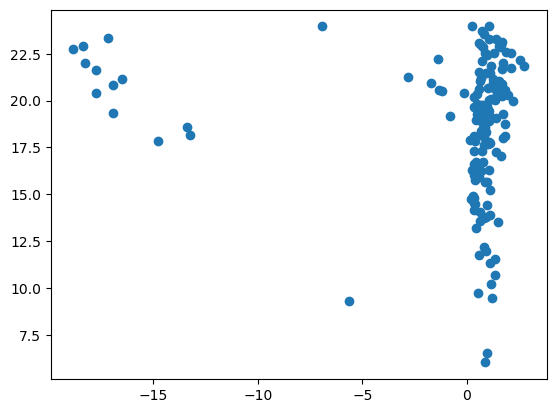

In [72]:
import pylab as pl
pl.scatter(nirspecarchive_mags['JWST/NIRCam.F182M']-nirspecarchive_mags['JWST/NIRCam.F212N'], nirspecarchive_mags['JWST/NIRCam.F212N'],)
colortocheck = nirspecarchive_mags['JWST/NIRCam.F182M']-nirspecarchive_mags['JWST/NIRCam.F212N']
colortocheck[~colortocheck.mask]

# Photometric Data on these stars

* NIR38 =  11:06:25.39, −77:23:15.70, J2000
* SSTSL2J110621.63-772354.1 (

In [21]:
from astroquery.vizier import Vizier
from astroquery.simbad import Simbad
from astropy.coordinates import SkyCoord
from astropy import units as u

In [24]:
Simbad.query_region(SkyCoord('11:06:25.39', '-77:23:15.70', frame='fk5', unit=(u.h, u.deg)),
                    radius=5*u.arcsec)

main_id,ra,dec,coo_err_maj,coo_err_min,coo_err_angle,coo_wavelength,coo_bibcode
,deg,deg,mas,mas,deg,,
object,float64,float64,float32,float32,int16,str1,object


In [25]:
Vizier.query_region(SkyCoord('11:06:25.39', '-77:23:15.70', frame='fk5', unit=(u.h, u.deg)),
                    radius=5*u.arcsec)

TableList with 7 tables:
	'0:I/353/gsc242' with 35 column(s) and 1 row(s) 
	'1:II/311/wise' with 22 column(s) and 1 row(s) 
	'2:II/328/allwise' with 28 column(s) and 1 row(s) 
	'3:II/363/unwise' with 11 column(s) and 1 row(s) 
	'4:II/365/catwise' with 38 column(s) and 1 row(s) 
	'5:II/367/vhs_dr5' with 38 column(s) and 2 row(s) 
	'6:II/368/sstsl2' with 37 column(s) and 1 row(s) 